In [1]:
from google.colab import drive
drive.mount("/content/drive")

# Create your project folder on Drive
import os
os.makedirs("/content/drive/MyDrive/sentiment_classifier/models", exist_ok=True)
os.makedirs("/content/drive/MyDrive/sentiment_classifier/data",   exist_ok=True)

print("✓ Drive mounted")
print("  Models will save to: /content/drive/MyDrive/sentiment_classifier/models/")
print("  Data will save to  : /content/drive/MyDrive/sentiment_classifier/data/")

Mounted at /content/drive
✓ Drive mounted
  Models will save to: /content/drive/MyDrive/sentiment_classifier/models/
  Data will save to  : /content/drive/MyDrive/sentiment_classifier/data/


In [2]:
import os
import re
import sys
import json
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
from torch.utils.data import Dataset

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    pipeline,
)

import evaluate

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline as SklearnPipeline
import joblib

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#F9F9F9",
    "axes.grid":        True,
    "grid.alpha":       0.35,
    "font.size":        11,
})

# ── Device setup ──────────────────────────────────────────────────────────────
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN    = 512
SEED       = 42
BATCH_SIZE = 16 if torch.cuda.is_available() else 8
NUM_EPOCHS = 3

os.makedirs("../models", exist_ok=True)
os.makedirs("../data",   exist_ok=True)
torch.manual_seed(SEED)
np.random.seed(SEED)

print("✓ Imports OK")
print(f"\n  Device     : {DEVICE}")
print(f"  Model      : {MODEL_NAME}")
print(f"  Max tokens : {MAX_LEN}")
print(f"  Batch size : {BATCH_SIZE}")
print(f"  Epochs     : {NUM_EPOCHS}")
if torch.cuda.is_available():
    print(f"  GPU        : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM       : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print(f"\n  ⚠ No GPU detected — training will take ~45 min")
    print(f"  → Upload to Google Colab (Runtime → T4 GPU) for ~8 min")

✓ Imports OK

  Device     : cuda
  Model      : distilbert-base-uncased
  Max tokens : 512
  Batch size : 16
  Epochs     : 3
  GPU        : Tesla T4
  VRAM       : 15.6 GB


## Load Data

In [3]:
train_df = pd.read_csv("imdb_train.csv")
val_df   = pd.read_csv("imdb_val.csv")
test_df  = pd.read_csv("imdb_test.csv")

print(f"Train : {len(train_df):,} reviews")
print(f"Val   : {len(val_df):,} reviews")
print(f"Test  : {len(test_df):,} reviews")
print(f"\nColumns: {list(train_df.columns)}")

# Verify labels are 0/1
assert set(train_df["label"].unique()) == {0, 1}, "Labels must be 0 and 1"
print(f"\nLabel distribution — train:")
print(f"  Positive (1): {(train_df['label']==1).sum():,}")
print(f"  Negative (0): {(train_df['label']==0).sum():,}")

train_df.head(3)

Train : 20,000 reviews
Val   : 5,000 reviews
Test  : 25,000 reviews

Columns: ['text', 'label', 'sentiment', 'word_count', 'char_count', 'split']

Label distribution — train:
  Positive (1): 10,000
  Negative (0): 10,000


,text,label,sentiment,word_count,char_count,split
0,I have always been a huge James Bond fanatic! ...,1,positive,399,2157,train
1,I am a Christian and I say this movie had terr...,0,negative,374,2170,train
2,"Neatly sandwiched between THE STRANGER, a smal...",1,positive,392,2317,train


## Text cleaning (for TF-IDF baseline only)

In [4]:
# DistilBERT receives RAW text — no cleaning needed
# This cleaner is ONLY for the TF-IDF baseline model

def clean_for_tfidf(text: str) -> str:
    """Light cleaning for TF-IDF baseline. Do NOT use for DistilBERT."""
    text = re.sub(r"<[^>]+>", " ", text)       # remove HTML
    text = re.sub(r"http\S+|www\S+", " ", text) # remove URLs
    text = re.sub(r"[^a-zA-Z\s']", " ", text)   # keep only letters
    text = text.lower()
    text = " ".join(text.split())
    return text


print("Cleaning text for TF-IDF baseline...")
train_df["clean_text"] = train_df["text"].apply(clean_for_tfidf)
val_df["clean_text"]   = val_df["text"].apply(clean_for_tfidf)
test_df["clean_text"]  = test_df["text"].apply(clean_for_tfidf)


Cleaning text for TF-IDF baseline...


## TF-IDF + Logistic Regression baseline

In [5]:
# Train baseline FIRST so we have a number to beat
# This is a critical discipline — always establish a baseline before deep learning

print("Training TF-IDF + Logistic Regression baseline...")
start = time.time()

baseline = SklearnPipeline([
    ("tfidf", TfidfVectorizer(
        max_features   = 50000,
        ngram_range    = (1, 2),    # unigrams + bigrams
        min_df         = 2,
        sublinear_tf   = True,      # log-scale TF
        strip_accents  = "unicode",
    )),
    ("clf", LogisticRegression(
        C             = 5.0,
        max_iter      = 1000,
        solver        = "lbfgs",
        random_state  = SEED,
        n_jobs        = -1,
    )),
])

baseline.fit(train_df["clean_text"], train_df["label"])
elapsed = time.time() - start

# Evaluate on validation set
val_preds_base  = baseline.predict(val_df["clean_text"])
val_probs_base  = baseline.predict_proba(val_df["clean_text"])[:, 1]
val_acc_base    = accuracy_score(val_df["label"], val_preds_base)
p, r, f1, _     = precision_recall_fscore_support(
    val_df["label"], val_preds_base, average="binary"
)

print(f"\n  Training time : {elapsed:.1f}s")
print(f"  Val accuracy  : {val_acc_base*100:.2f}%")
print(f"  Val precision : {p*100:.2f}%")
print(f"  Val recall    : {r*100:.2f}%")
print(f"  Val F1        : {f1*100:.2f}%")

# Save baseline
DRIVE_MODELS = "/content/drive/MyDrive/sentiment_classifier/models"

joblib.dump(baseline, f"{DRIVE_MODELS}/tfidf_logreg_baseline.joblib")
print(f"✓ Baseline saved → {DRIVE_MODELS}/tfidf_logreg_baseline.joblib")
print(f"  Target to beat: {val_acc_base*100:.2f}% accuracy on val set")

BASELINE_ACC = val_acc_base

Training TF-IDF + Logistic Regression baseline...

  Training time : 14.9s
  Val accuracy  : 90.54%
  Val precision : 90.04%
  Val recall    : 91.16%
  Val F1        : 90.60%
✓ Baseline saved → /content/drive/MyDrive/sentiment_classifier/models/tfidf_logreg_baseline.joblib
  Target to beat: 90.54% accuracy on val set


##  Load DistilBERT tokenizer

In [6]:
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

print(f"✓ Tokenizer loaded")
print(f"  Vocab size    : {tokenizer.vocab_size:,}")
print(f"  Max length    : {tokenizer.model_max_length}")
print(f"  Special tokens: {tokenizer.all_special_tokens}")

# Show a tokenized example
sample_text = "This film was absolutely brilliant. The acting was superb!"
tokens = tokenizer(
    sample_text,
    padding          = "max_length",
    truncation       = True,
    max_length       = 32,
    return_tensors   = "pt",
)

print(f"\nSample tokenization:")
print(f"  Text     : '{sample_text}'")
print(f"  Token IDs: {tokens['input_ids'][0].tolist()}")
print(f"  Tokens   : {tokenizer.convert_ids_to_tokens(tokens['input_ids'][0])}")
print(f"  Attention: {tokens['attention_mask'][0].tolist()}")
print(f"\n  [CLS] at position 0  — classification token")
print(f"  [SEP] at end         — separator token")
print(f"  [PAD] fills to 32    — ignored by attention mask (value=0)")

Loading tokenizer: distilbert-base-uncased


✓ Tokenizer loaded
  Vocab size    : 30,522
  Max length    : 512
  Special tokens: ['[UNK]', '[SEP]', '[PAD]', '[CLS]', '[MASK]']

Sample tokenization:
  Text     : 'This film was absolutely brilliant. The acting was superb!'
  Token IDs: [101, 2023, 2143, 2001, 7078, 8235, 1012, 1996, 3772, 2001, 21688, 999, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Tokens   : ['[CLS]', 'this', 'film', 'was', 'absolutely', 'brilliant', '.', 'the', 'acting', 'was', 'superb', '!', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
  Attention: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

  [CLS] at position 0  — classification token
  [SEP] at end         — separator token
  [PAD] fills to 32    — ignored by attention mask (value=0)


## Build PyTorch Dataset

In [7]:
class IMDbDataset(Dataset):
    """
    PyTorch Dataset wrapping tokenized IMDb reviews.

    Tokenization happens at __getitem__ time to keep memory low.
    Each item returns: input_ids, attention_mask, labels.
    """

    def __init__(self,
                 texts:     list,
                 labels:    list,
                 tokenizer,
                 max_length: int = 512):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding          = "max_length",
            truncation       = True,
            max_length       = self.max_len,
            return_tensors   = "pt",
        )
        return {
            "input_ids":      encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long),
        }


# Instantiate datasets
train_dataset = IMDbDataset(
    train_df["text"].tolist(), train_df["label"].tolist(), tokenizer, MAX_LEN
)
val_dataset   = IMDbDataset(
    val_df["text"].tolist(),   val_df["label"].tolist(),   tokenizer, MAX_LEN
)
test_dataset  = IMDbDataset(
    test_df["text"].tolist(),  test_df["label"].tolist(),  tokenizer, MAX_LEN
)

print(f"✓ Datasets created")
print(f"  Train dataset : {len(train_dataset):,} items")
print(f"  Val dataset   : {len(val_dataset):,} items")
print(f"  Test dataset  : {len(test_dataset):,} items")

# Verify one item
sample_item = train_dataset[0]
print(f"\nSample item keys  : {list(sample_item.keys())}")
print(f"input_ids shape   : {sample_item['input_ids'].shape}")
print(f"attention_mask    : {sample_item['attention_mask'].shape}")
print(f"label             : {sample_item['labels'].item()}")

✓ Datasets created
  Train dataset : 20,000 items
  Val dataset   : 5,000 items
  Test dataset  : 25,000 items

Sample item keys  : ['input_ids', 'attention_mask', 'labels']
input_ids shape   : torch.Size([512])
attention_mask    : torch.Size([512])
label             : 1


## Load DistilBERT model

In [8]:
print(f"Loading model: {MODEL_NAME}")

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels = 2,
)
model = model.to(DEVICE)

# Count parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✓ Model loaded and moved to {DEVICE}")
print(f"\n  Total parameters     : {total_params:,}")
print(f"  Trainable parameters : {trainable_params:,}")
print(f"  Model size (approx)  : {total_params * 4 / 1e6:.0f} MB")


Loading model: distilbert-base-uncased


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Model loaded and moved to cuda

  Total parameters     : 66,955,010
  Trainable parameters : 66,955,010
  Model size (approx)  : 268 MB


## Define compute_metrics function

In [9]:
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    """
    Called by Trainer at the end of each evaluation step.
    Returns accuracy and F1 score.
    """
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=-1)

    acc = accuracy_metric.compute(
        predictions=predictions, references=labels
    )["accuracy"]

    p, r, f1, _ = precision_recall_fscore_support(
        labels, predictions, average="binary"
    )

    return {
        "accuracy":  round(acc,  4),
        "f1":        round(f1,   4),
        "precision": round(p,    4),
        "recall":    round(r,    4),
    }


print("✓ compute_metrics defined")
print("  Metrics logged per epoch: accuracy, F1, precision, recall")

✓ compute_metrics defined
  Metrics logged per epoch: accuracy, F1, precision, recall


## Training arguments

In [10]:
DRIVE_MODELS = "/content/drive/MyDrive/sentiment_classifier/models"
training_args = TrainingArguments(

    # ── Output ────────────────────────────────────────────────────────────
    output_dir = f"{DRIVE_MODELS}/distilbert-imdb",


    # ── Training schedule ─────────────────────────────────────────────────
    num_train_epochs        = NUM_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE * 2,

    # ── Optimiser ─────────────────────────────────────────────────────────
    learning_rate           = 2e-5,
    weight_decay            = 0.01,
    warmup_ratio            = 0.1,      # 10% of steps for LR warmup
    lr_scheduler_type       = "linear",

    # ── Evaluation & saving ───────────────────────────────────────────────
    eval_strategy           = "epoch",
    save_strategy           = "epoch",
    load_best_model_at_end  = True,
    metric_for_best_model   = "f1",
    greater_is_better       = True,

    # ── Logging ───────────────────────────────────────────────────────────
    logging_dir             = "../models/logs",
    logging_steps           = 100,
    logging_first_step      = True,
    report_to               = "none",   # set "mlflow" if you want MLflow logging

    # ── Reproducibility ───────────────────────────────────────────────────
    seed                    = SEED,
    data_seed               = SEED,

    # ── Performance ───────────────────────────────────────────────────────
    fp16                    = torch.cuda.is_available(),  # mixed precision on GPU
    dataloader_num_workers  = 0,        # set to 4 on Linux with GPU
    gradient_accumulation_steps = 1,
)

print("✓ TrainingArguments configured")
print(f"\n  Learning rate    : {training_args.learning_rate}")
print(f"  Warmup ratio     : {training_args.warmup_ratio}")
print(f"  Weight decay     : {training_args.weight_decay}")
print(f"  Mixed precision  : {training_args.fp16} (fp16)")
print(f"  Best model metric: {training_args.metric_for_best_model}")
print(f"\nWhy these values?")
print(f"  lr=2e-5    : Standard for fine-tuning transformers (too high = catastrophic forgetting)")
print(f"  warmup=10% : Gradually increases LR to avoid early instability")
print(f"  fp16=True  : Halves memory use on GPU, ~2x faster training")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


✓ TrainingArguments configured

  Learning rate    : 2e-05
  Warmup ratio     : 0.1
  Weight decay     : 0.01
  Mixed precision  : True (fp16)
  Best model metric: f1

Why these values?
  lr=2e-5    : Standard for fine-tuning transformers (too high = catastrophic forgetting)
  warmup=10% : Gradually increases LR to avoid early instability
  fp16=True  : Halves memory use on GPU, ~2x faster training


## Train DistilBERT

In [11]:
trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Starting fine-tuning...")
print(f"  Train samples : {len(train_dataset):,}")
print(f"  Val samples   : {len(val_dataset):,}")
print(f"  Batch size    : {BATCH_SIZE}")
print(f"  Epochs        : {NUM_EPOCHS}")
steps_per_epoch = len(train_dataset) // BATCH_SIZE
print(f"  Steps/epoch   : {steps_per_epoch:,}")
print(f"  Total steps   : {steps_per_epoch * NUM_EPOCHS:,}")
print()

train_result = trainer.train()

print(f"\n✓ Training complete!")
print(f"  Total training time : {train_result.metrics['train_runtime']:.0f}s "
      f"({train_result.metrics['train_runtime']/60:.1f} min)")
print(f"  Samples/second      : {train_result.metrics['train_samples_per_second']:.1f}")
print(f"  Final train loss    : {train_result.metrics['train_loss']:.4f}")

Starting fine-tuning...
  Train samples : 20,000
  Val samples   : 5,000
  Batch size    : 16
  Epochs        : 3
  Steps/epoch   : 1,250
  Total steps   : 3,750



Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.246302,0.207596,0.925800,0.926700,0.915700,0.938000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.246302,0.207596,0.925800,0.926700,0.915700,0.938000
2,0.196329,0.230928,0.928000,0.926200,0.949600,0.904000
3,0.095757,0.295689,0.928400,0.928400,0.928100,0.928800


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



✓ Training complete!
  Total training time : 982s (16.4 min)
  Samples/second      : 61.1
  Final train loss    : 0.1905


##  Plot training curves


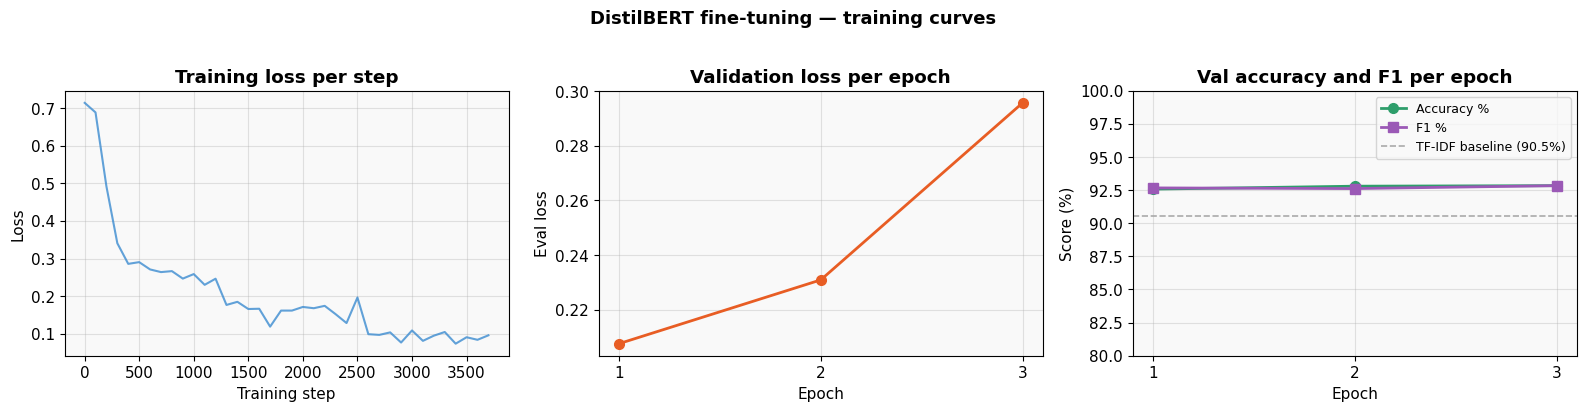

Best epoch metrics:
  Epoch    : 3.0
  Val loss : 0.2957
  Accuracy : 92.84%
  F1       : 92.84%


In [12]:
# Extract loss and metric history from trainer logs

history = trainer.state.log_history

train_loss_steps = [(e["step"], e["loss"])
                    for e in history if "loss" in e and "eval_loss" not in e]
eval_entries     = [e for e in history if "eval_loss" in e]

steps_tr   = [s for s, _ in train_loss_steps]
losses_tr  = [l for _, l in train_loss_steps]

epochs_ev  = [e.get("epoch", i+1) for i, e in enumerate(eval_entries)]
losses_ev  = [e["eval_loss"]      for e in eval_entries]
accs_ev    = [e["eval_accuracy"]  for e in eval_entries]
f1s_ev     = [e["eval_f1"]        for e in eval_entries]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Left — training loss
ax = axes[0]
ax.plot(steps_tr, losses_tr, color="#3B8BD0", lw=1.5, alpha=0.8)
ax.set_xlabel("Training step")
ax.set_ylabel("Loss")
ax.set_title("Training loss per step", fontweight="bold")

# Middle — eval loss per epoch
ax = axes[1]
ax.plot(epochs_ev, losses_ev, color="#E85D24", lw=2,
        marker="o", ms=7, label="Eval loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Eval loss")
ax.set_title("Validation loss per epoch", fontweight="bold")
ax.set_xticks(epochs_ev)

# Right — eval metrics
ax = axes[2]
ax.plot(epochs_ev, [a*100 for a in accs_ev],
        color="#2E9E6B", lw=2, marker="o", ms=7, label="Accuracy %")
ax.plot(epochs_ev, [f*100 for f in f1s_ev],
        color="#9B59B6", lw=2, marker="s", ms=7, label="F1 %")
ax.axhline(BASELINE_ACC * 100, color="#AAA", lw=1.2,
           linestyle="--", label=f"TF-IDF baseline ({BASELINE_ACC*100:.1f}%)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Score (%)")
ax.set_title("Val accuracy and F1 per epoch", fontweight="bold")
ax.legend(fontsize=9)
ax.set_xticks(epochs_ev)
ax.set_ylim(80, 100)

plt.suptitle("DistilBERT fine-tuning — training curves",
             fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../data/training_curves.png", dpi=130, bbox_inches="tight")
plt.show()

print("Best epoch metrics:")
best_idx = int(np.argmax(f1s_ev))
print(f"  Epoch    : {epochs_ev[best_idx]}")
print(f"  Val loss : {losses_ev[best_idx]:.4f}")
print(f"  Accuracy : {accs_ev[best_idx]*100:.2f}%")
print(f"  F1       : {f1s_ev[best_idx]*100:.2f}%")

## Save model and tokenizer

In [13]:
DRIVE_MODELS = "/content/drive/MyDrive/sentiment_classifier/models"
SAVE_PATH    = f"{DRIVE_MODELS}/distilbert-imdb"

trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

# Save training meta JSON to Drive too
import json
meta = {
    "model_name":    MODEL_NAME,
    "max_length":    MAX_LEN,
    "num_epochs":    NUM_EPOCHS,
    "batch_size":    BATCH_SIZE,
    "learning_rate": training_args.learning_rate,
    "weight_decay":  training_args.weight_decay,
    "warmup_ratio":  training_args.warmup_ratio,
    "seed":          SEED,
    "best_val_f1":   round(max(f1s_ev), 4),
    "best_val_acc":  round(max(accs_ev), 4),
    "baseline_acc":  round(BASELINE_ACC, 4),
}
with open(f"{SAVE_PATH}/training_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print(f"✓ Model saved → {SAVE_PATH}/")
print(f"\nFiles on Drive:")
for fname in sorted(os.listdir(SAVE_PATH)):
    size_kb = os.path.getsize(f"{SAVE_PATH}/{fname}") / 1024
    print(f"  {fname:<45} {size_kb:>8.1f} KB")


print(f"\nTo reload the model anywhere:")
print(f"  from transformers import pipeline")
print(f"  clf = pipeline('sentiment-analysis',")
print(f"                 model='../models/distilbert-imdb')")
print(f"  clf('This film was absolutely brilliant!')")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Model saved → /content/drive/MyDrive/sentiment_classifier/models/distilbert-imdb/

Files on Drive:
  checkpoint-1250                                    4.0 KB
  checkpoint-2500                                    4.0 KB
  checkpoint-3750                                    4.0 KB
  config.json                                        0.6 KB
  model.safetensors                             261555.2 KB
  tokenizer.json                                   695.0 KB
  tokenizer_config.json                              0.3 KB
  training_args.bin                                  5.1 KB
  training_meta.json                                 0.3 KB

To reload the model anywhere:
  from transformers import pipeline
  clf = pipeline('sentiment-analysis',
                 model='../models/distilbert-imdb')
  clf('This film was absolutely brilliant!')


## Evaluate on full test set

In [14]:
# Run inference on 25,000 test reviews
# This is the ONLY time we touch the test set

print("Running inference on full test set (25,000 reviews)...")
print("(Takes ~5 min on CPU, ~1 min on GPU)\n")

test_results = trainer.predict(test_dataset)
test_logits  = test_results.predictions
test_labels  = test_results.label_ids

test_preds   = np.argmax(test_logits, axis=-1)
test_probs   = torch.softmax(
    torch.tensor(test_logits), dim=-1
).numpy()[:, 1]   # probability of positive class

# Metrics
test_acc       = accuracy_score(test_labels, test_preds)
p, r, f1, _    = precision_recall_fscore_support(
    test_labels, test_preds, average="binary"
)
auc            = roc_auc_score(test_labels, test_probs)

print("─" * 50)
print("  Final Test Set Results")
print("─" * 50)
print(f"\n  Accuracy  : {test_acc*100:.2f}%")
print(f"  Precision : {p*100:.2f}%")
print(f"  Recall    : {r*100:.2f}%")
print(f"  F1        : {f1*100:.2f}%")
print(f"  ROC-AUC   : {auc:.4f}")
print(f"\n  TF-IDF baseline accuracy : {BASELINE_ACC*100:.2f}%")
print(f"  DistilBERT improvement   : +{(test_acc - BASELINE_ACC)*100:.2f}%")

# Save predictions for notebook 04
test_df["pred_label"] = test_preds
test_df["prob_pos"]   = test_probs
test_df["prob_neg"]   = 1 - test_probs
test_df["pred_sentiment"] = test_df["pred_label"].map(
    {1: "positive", 0: "negative"}
)
test_df["correct"] = (test_df["pred_label"] == test_df["label"])
test_df["confidence"] = test_df[["prob_pos","prob_neg"]].max(axis=1)
DRIVE_DATA = "/content/drive/MyDrive/sentiment_classifier/data"

test_df.to_csv(f"{DRIVE_DATA}/test_predictions.csv", index=False)
print(f"✓ Predictions saved → {DRIVE_DATA}/test_predictions.csv")

Running inference on full test set (25,000 reviews)...
(Takes ~5 min on CPU, ~1 min on GPU)



──────────────────────────────────────────────────
  Final Test Set Results
──────────────────────────────────────────────────

  Accuracy  : 92.82%
  Precision : 92.44%
  Recall    : 93.27%
  F1        : 92.86%
  ROC-AUC   : 0.9788

  TF-IDF baseline accuracy : 90.54%
  DistilBERT improvement   : +2.28%
✓ Predictions saved → /content/drive/MyDrive/sentiment_classifier/data/test_predictions.csv


## Confusion matrix and classification report

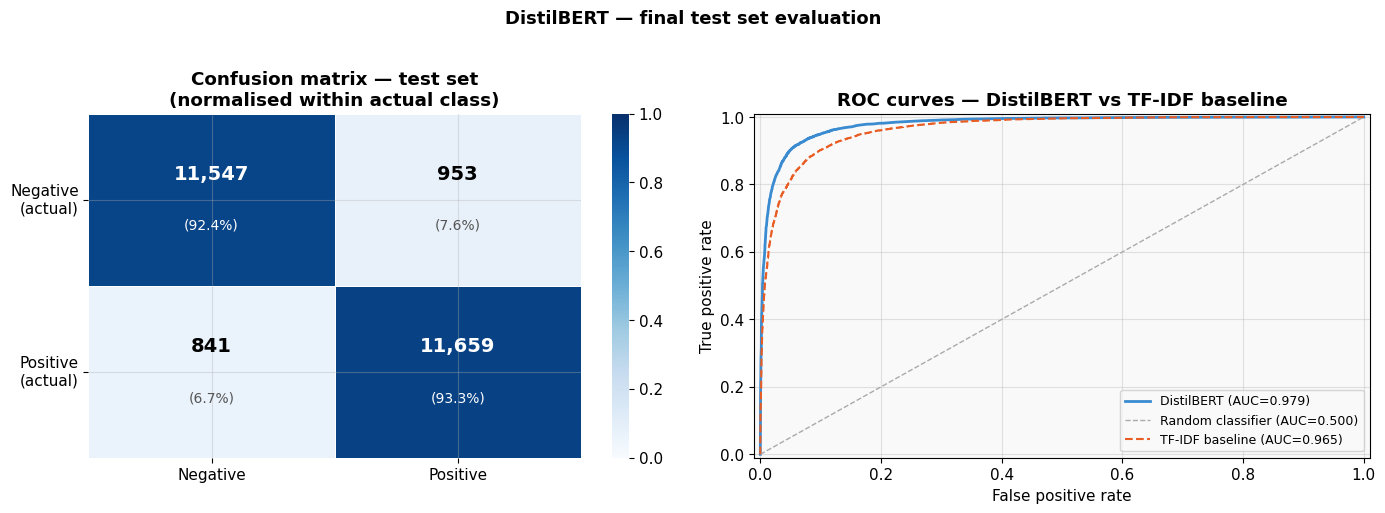

Classification report:
              precision    recall  f1-score   support

    Negative       0.93      0.92      0.93     12500
    Positive       0.92      0.93      0.93     12500

    accuracy                           0.93     25000
   macro avg       0.93      0.93      0.93     25000
weighted avg       0.93      0.93      0.93     25000



In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — confusion matrix
ax   = axes[0]
cm   = confusion_matrix(test_labels, test_preds)
cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)   # normalised

labels = ["Negative\n(pred)", "Positive\n(pred)"]
sns.heatmap(
    cm_n, annot=False,
    cmap="Blues", ax=ax,
    linewidths=0.5, linecolor="white",
    vmin=0, vmax=1,
)
for i in range(2):
    for j in range(2):
        ax.text(
            j + 0.5, i + 0.35,
            f"{cm[i,j]:,}",
            ha="center", va="center",
            fontsize=14, fontweight="bold",
            color="white" if cm_n[i,j] > 0.6 else "black",
        )
        ax.text(
            j + 0.5, i + 0.65,
            f"({cm_n[i,j]*100:.1f}%)",
            ha="center", va="center",
            fontsize=10,
            color="white" if cm_n[i,j] > 0.6 else "#555",
        )
ax.set_xticklabels(["Negative", "Positive"])
ax.set_yticklabels(["Negative\n(actual)", "Positive\n(actual)"], rotation=0)
ax.set_title("Confusion matrix — test set\n(normalised within actual class)",
             fontweight="bold")

# Right — ROC curve
ax  = axes[1]
fpr, tpr, _ = roc_curve(test_labels, test_probs)
ax.plot(fpr, tpr, color="#3B8BD0", lw=2, label=f"DistilBERT (AUC={auc:.3f})")
ax.plot([0,1], [0,1], color="#AAA", lw=1, linestyle="--",
        label="Random classifier (AUC=0.500)")

# Add TF-IDF baseline ROC
base_probs    = baseline.predict_proba(test_df["clean_text"])[:, 1]
base_auc      = roc_auc_score(test_labels, base_probs)
fpr_b, tpr_b, _ = roc_curve(test_labels, base_probs)
ax.plot(fpr_b, tpr_b, color="#E85D24", lw=1.5,
        linestyle="--", label=f"TF-IDF baseline (AUC={base_auc:.3f})")

ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curves — DistilBERT vs TF-IDF baseline",
             fontweight="bold")
ax.legend(fontsize=9)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)

plt.suptitle("DistilBERT — final test set evaluation",
             fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../data/confusion_matrix_roc.png", dpi=130, bbox_inches="tight")
plt.show()

print("Classification report:")
print(classification_report(
    test_labels, test_preds,
    target_names=["Negative", "Positive"]
))

##  Confidence score analysis

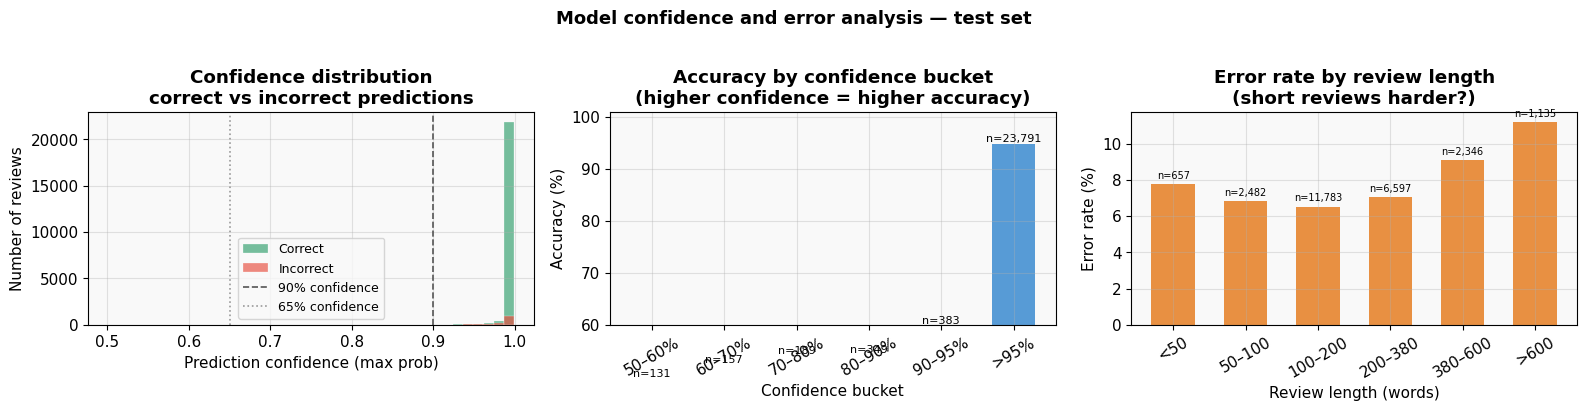

Low-confidence predictions (<65%): 196 reviews
  Accuracy in this range: 51.0%
  (vs 92.8% overall) — these are genuinely hard reviews


In [16]:
# Where is the model uncertain? Low confidence = harder reviews

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Left — confidence histogram
ax = axes[0]
correct_conf   = test_df[test_df["correct"]]["confidence"]
incorrect_conf = test_df[~test_df["correct"]]["confidence"]

ax.hist(correct_conf,   bins=40, alpha=0.65, color="#2E9E6B",
        label="Correct", edgecolor="white", linewidth=0.3)
ax.hist(incorrect_conf, bins=40, alpha=0.65, color="#E74C3C",
        label="Incorrect", edgecolor="white", linewidth=0.3)
ax.axvline(0.9,  color="#555", lw=1.2, linestyle="--", label="90% confidence")
ax.axvline(0.65, color="#999", lw=1.2, linestyle=":",  label="65% confidence")
ax.set_xlabel("Prediction confidence (max prob)")
ax.set_ylabel("Number of reviews")
ax.set_title("Confidence distribution\ncorrect vs incorrect predictions",
             fontweight="bold")
ax.legend(fontsize=9)

# Middle — accuracy by confidence bucket
ax = axes[1]
bins_     = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.01]
labels_   = ["50–60%","60–70%","70–80%","80–90%","90–95%",">95%"]
test_df["conf_bucket"] = pd.cut(
    test_df["confidence"], bins=bins_, labels=labels_
)
bucket_acc = test_df.groupby("conf_bucket", observed=True)["correct"].mean()
bucket_cnt = test_df.groupby("conf_bucket", observed=True)["correct"].count()

bars = ax.bar(bucket_acc.index, bucket_acc.values * 100,
              color="#3B8BD0", alpha=0.85, width=0.6)
for bar, count in zip(bars, bucket_cnt.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f"n={count:,}", ha="center", fontsize=8)
ax.set_xlabel("Confidence bucket")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy by confidence bucket\n(higher confidence = higher accuracy)",
             fontweight="bold")
ax.set_ylim(60, 101)
ax.tick_params(axis="x", rotation=30)

# Right — error rate by review length
ax = axes[2]
bins_len   = [0, 50, 100, 200, 380, 600, 10000]
labels_len = ["<50","50–100","100–200","200–380","380–600",">600"]
test_df["len_bucket"] = pd.cut(
    test_df["word_count"], bins=bins_len, labels=labels_len
)
err_by_len = (
    test_df.groupby("len_bucket", observed=True)["correct"]
    .agg(["mean","count"])
)
ax.bar(err_by_len.index,
       (1 - err_by_len["mean"]) * 100,
       color="#E67E22", alpha=0.85, width=0.6)
ax.set_xlabel("Review length (words)")
ax.set_ylabel("Error rate (%)")
ax.set_title("Error rate by review length\n(short reviews harder?)",
             fontweight="bold")
ax.tick_params(axis="x", rotation=30)
for i, (idx, row) in enumerate(err_by_len.iterrows()):
    ax.text(i, (1 - row["mean"]) * 100 + 0.3,
            f"n={int(row['count']):,}", ha="center", fontsize=7)

plt.suptitle("Model confidence and error analysis — test set",
             fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../data/confidence_analysis.png", dpi=130, bbox_inches="tight")
plt.show()

low_conf = test_df[test_df["confidence"] < 0.65]
print(f"Low-confidence predictions (<65%): {len(low_conf):,} reviews")
print(f"  Accuracy in this range: {low_conf['correct'].mean()*100:.1f}%")
print(f"  (vs {test_acc*100:.1f}% overall) — these are genuinely hard reviews")

## Inspect errors — what did the model get wrong?

In [17]:
# Manually read wrong predictions — this is critical for interview discussions
# "I looked at my model's mistakes" is a huge green flag to interviewers

errors = test_df[~test_df["correct"]].copy()

print(f"Total errors: {len(errors):,} / {len(test_df):,} "
      f"({len(errors)/len(test_df)*100:.1f}%)\n")

# Wrong positives (model said positive, was negative)
false_pos = errors[errors["pred_sentiment"] == "positive"].sort_values(
    "confidence", ascending=False
)
# Wrong negatives (model said negative, was positive)
false_neg = errors[errors["pred_sentiment"] == "negative"].sort_values(
    "confidence", ascending=False
)

print("═" * 60)
print("  FALSE POSITIVES — model said POSITIVE, actually NEGATIVE")
print("  (high confidence wrong predictions — most interesting)")
print("═" * 60)

for _, row in false_pos.head(3).iterrows():
    print(f"\n  Confidence: {row['confidence']*100:.1f}%")
    print(f"  Actual    : NEGATIVE")
    print(f"  Review    : {row['text'][:350]}...")
    print()

print("═" * 60)
print("  FALSE NEGATIVES — model said NEGATIVE, actually POSITIVE")
print("═" * 60)

for _, row in false_neg.head(3).iterrows():
    print(f"\n  Confidence: {row['confidence']*100:.1f}%")
    print(f"  Actual    : POSITIVE")
    print(f"  Review    : {row['text'][:350]}...")
    print()

print("Common error patterns to look for:")
print("  - Sarcasm / irony  : 'Oh great, another terrible sequel'")
print("  - Mixed sentiment  : 'Amazing visuals, terrible plot'")
print("  - Negation chains  : 'Not entirely without some merit'")
print("  - Spoiler warnings : Review starts negative, ends positive")

Total errors: 1,794 / 25,000 (7.2%)

════════════════════════════════════════════════════════════
  FALSE POSITIVES — model said POSITIVE, actually NEGATIVE
  (high confidence wrong predictions — most interesting)
════════════════════════════════════════════════════════════

  Confidence: 99.8%
  Actual    : NEGATIVE
  Review    : The Brave One is about a New York radio show host named Erica Bain (Jodie Foster). Her life is a dream living in the city she grew up in and loves. She has her great fiancé David (Naveen Andrews), whom she is planning to marry. But one night while Erica and David are out walking their dog, they are attacked and mugged by a group of degenerates, lea...


  Confidence: 99.8%
  Actual    : NEGATIVE
  Review    : Lois Weber's film "Hypocrites" was and still kind of is a very bold and daring film. I enjoyed it and was very impressed by the filming and story of it. The priest sees the hypocrisy of the people in his church and tries to show them the "naked" truth. T

## Full metrics comparison table

In [18]:
# Final side-by-side comparison — put this in your README

# TF-IDF on test set
base_test_preds = baseline.predict(test_df["clean_text"])
base_test_probs = baseline.predict_proba(test_df["clean_text"])[:, 1]
b_acc           = accuracy_score(test_labels, base_test_preds)
b_p, b_r, b_f1, _ = precision_recall_fscore_support(
    test_labels, base_test_preds, average="binary"
)
b_auc = roc_auc_score(test_labels, base_test_probs)

results_table = pd.DataFrame({
    "Model":     ["TF-IDF + Logistic Regression", "DistilBERT (fine-tuned)"],
    "Accuracy":  [f"{b_acc*100:.2f}%",  f"{test_acc*100:.2f}%"],
    "Precision": [f"{b_p*100:.2f}%",    f"{p*100:.2f}%"],
    "Recall":    [f"{b_r*100:.2f}%",    f"{r*100:.2f}%"],
    "F1":        [f"{b_f1*100:.2f}%",   f"{f1*100:.2f}%"],
    "ROC-AUC":   [f"{b_auc:.4f}",       f"{auc:.4f}"],
    "Train time": ["~10s (CPU)",         "~8min (GPU) / ~45min (CPU)"],
}).set_index("Model")

print("═" * 65)
print("  Final results — test set (25,000 reviews)")
print("═" * 65)
display(results_table)

improvement = test_acc - b_acc
print(f"\n  DistilBERT improvement over TF-IDF: +{improvement*100:.2f}% accuracy")
print(f"\nResume bullet:")
print(f"  'Fine-tuned DistilBERT on IMDb (25k reviews); achieved")
print(f"  {test_acc*100:.1f}% accuracy and {f1:.3f} F1, outperforming a")
print(f"  TF-IDF + logistic regression baseline by {improvement*100:.1f}%'")

DRIVE_DATA = "/content/drive/MyDrive/sentiment_classifier/data"

results_table.to_csv(f"{DRIVE_DATA}/model_comparison.csv")
print(f"✓ Saved → {DRIVE_DATA}/model_comparison.csv")

═════════════════════════════════════════════════════════════════
  Final results — test set (25,000 reviews)
═════════════════════════════════════════════════════════════════


,Accuracy,Precision,Recall,F1,ROC-AUC,Train time
Model,,,,,,
TF-IDF + Logistic Regression,90.08%,89.90%,90.30%,90.10%,0.9647,~10s (CPU)
DistilBERT (fine-tuned),92.82%,92.44%,93.27%,92.86%,0.9788,~8min (GPU) / ~45min (CPU)



  DistilBERT improvement over TF-IDF: +2.74% accuracy

Resume bullet:
  'Fine-tuned DistilBERT on IMDb (25k reviews); achieved
  92.8% accuracy and 0.929 F1, outperforming a
  TF-IDF + logistic regression baseline by 2.7%'
✓ Saved → /content/drive/MyDrive/sentiment_classifier/data/model_comparison.csv
